> **⚠️ 2026-07-05d amendment (post-review).** The §4 "F closed / physical floor" verdict was
> **partially overstated**: the 10.2% overlap disagreement quoted below is the RAW value — after
> the minnaert correction it is **4.0%** (worst pairs 0.7–4%), yet predictions still differ ~20%
> even where corrected inputs agree to <1%. The real floor = embedder amplification (no
> cross-frame loss term) + one anomalous frame — both addressable. The **input-mapping leg**
> remains closed, but a Phase-2 invariance & leveling docket (H1–H6) is now open:
> PLAN_StripingArtifact "PHASE 2", DECISIONS 2026-07-05d,
> `reports/f_leg_b/review_overlap_residual.csv`. Everything else in this notebook stands.
>
> **⚠️ 2026-07-07 update — Phase-2 H1 (per-frame log-median centering) DONE, both gates PASS.**
> Adding a per-crop median-centering step to the log-minnaert recipe (`minnaert_center` mapping)
> cut η² median composite **0.179 → 0.081** (partition 0.277 → 0.128, both below the A1 fix at
> 0.141) at skill Δ −0.0139, and — the decisive point — dropped prediction overlap disagreement to
> **0.073**, now *below* the 0.102 input I/F disagreement. **The embedder amplification the review
> predicted is gone**; residual structure is almost entirely the one anomalous frame (F02). H1
> halves the artifact but does not yet reach the η² ≲ 0.05 reopening bar, so the docket continues
> at H2 (embedding nuisance-subspace removal). See DECISIONS 2026-07-07,
> `reports/figures/f_pilot_minnaert_center.png`.
>
> **⚠️ 2026-07-09 update — Phase-2 H2 (embedding nuisance-subspace removal) DONE: FAIL, refuted.**
> Projecting out the top-k PCA directions of co-located between-frame embedding differences does
> NOT reduce the partition η² at any k, *worsens* co-located prediction agreement, and destroys
> skill as k grows. The artifact is **not a fixed low-rank linear subspace** of the embedding —
> H1 stays the operating baseline and the docket continues at H3 (consistency-regularized head)
> / H4 (overlap-constrained leveling). Full record: §6 below, DECISIONS 2026-07-09.
>
> **⚠️ 2026-07-09b update — H3 FAIL, then H4 PILOT PASS (mechanically).** H3 (a consistency
> penalty in the head's loss) *does* drive η² down but only by collapsing the head's dynamic range,
> so skill falls on the same axis — no operating point clears both gates (§7). **H4** — a
> *post-hoc* per-frame additive **leveling** of the predictions — succeeds where H2/H3 failed
> because it acts on the axis orthogonal to within-frame ranking: partition η² **0.128 → 0.0505**
> and the held-out overlap disagreement **halves** (0.074 → 0.035), with skill preserved *by
> construction* (§8). One caveat gates the reopening call: a **trend guard** flags that 58% of the
> offsets form a smooth spatial plane the 7-frame pilot can't cleanly separate from a real regional
> gradient. Full record: §7–§8 below, DECISIONS 2026-07-09b.


# 28 — F verdict: skill preserved, artifact NOT removed → F closed

**The question F was meant to answer.** The regional abundance map shows a rectangular
"striping" artifact: adjacent CTX **source frames** in the Murray mosaic carry slightly different
radiometry, and the texture model amplifies those invisible differences into visible blocks
(notebook 25; η² 0.011 vs 0.002 null). **Mitigation F** = skip the mosaic, run inference directly
on ISIS-`ctxcal`-calibrated CTX source frames (physical I/F, no per-frame mosaic stretch), on the
bet that calibrated frames agree well enough to remove the blocks at source.

**F has to clear two independent bars**, and this notebook consolidates both:

| test | measures | result |
|---|---|---|
| **Skill gate** (LOIO, notebook 27) | within-scene rich/poor ranking | **PASS** (Δ median +0.0067) |
| **η² artifact test** (this notebook) | same-ground agreement ACROSS frames | **FAIL** (η² 0.179; blocks visible) |

They are *different failure modes*, and F splits them: it preserves skill but does not remove the
artifact. Below: how the mapping iteration got to the skill PASS (§1–2), the decisive η² test
(§3), and why F is closed (§4).


In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
import src.modeling  # noqa: F401  OpenMP bootstrap; must precede numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

FIG = REPO / "reports" / "figures"
LEGB = REPO / "reports" / "f_leg_b"

variant = pd.read_csv(LEGB / "variant_summary.csv", index_col=0)
eta = pd.read_csv(FIG / "f_pilot_eta2_summary.csv")
print(f"variant table: {variant.shape[0]} images × {variant.shape[1]} columns")
print(f"eta2 rows (minnaert_log): {len(eta)}")


variant table: 36 images × 8 columns
eta2 rows (minnaert_log): 3


## §1 — The skill gate: five mappings to a PASS

Leg B first FAILED with the perframe mapping (−0.0499; notebook 27). Diagnostics pointed at the
I/F→uint8 **mapping**, not F itself, so we iterated the mapping family (all on the same retrained
embeddings, same LOIO folds, same 36 common images). The gate is Δ median per-image AUC ≥ −0.02
vs the mosaic baseline (0.786).


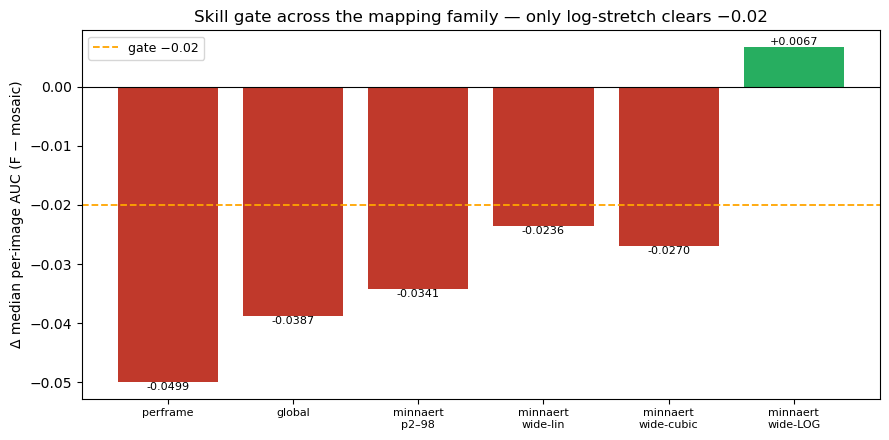

win/loss vs baseline per variant:
  perframe         Δmed -0.0499  win 11  loss 25  below0.5 8
  global           Δmed -0.0387  win 11  loss 25  below0.5 1
  minn_p2_98       Δmed -0.0341  win 14  loss 22  below0.5 2
  minn_wide_lin    Δmed -0.0236  win 16  loss 20  below0.5 2
  minn_wide_cubic  Δmed -0.0270  win 17  loss 19  below0.5 2
  minn_wide_LOG    Δmed +0.0067  win 18  loss 18  below0.5 3


In [2]:
# Δ median AUC per variant, computed from the per-image table
base_med = variant["baseline"].median()
order = ["perframe", "global", "minn_p2_98", "minn_wide_lin", "minn_wide_cubic", "minn_wide_LOG"]
labels = ["perframe", "global", "minnaert\np2–98", "minnaert\nwide-lin",
          "minnaert\nwide-cubic", "minnaert\nwide-LOG"]
dmed = [variant[c].median() - base_med for c in order]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#27ae60" if d >= -0.02 else "#c0392b" for d in dmed]
bars = ax.bar(range(len(order)), dmed, color=colors)
ax.axhline(-0.02, color="orange", ls="--", lw=1.3, label="gate −0.02")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Δ median per-image AUC (F − mosaic)")
ax.set_title("Skill gate across the mapping family — only log-stretch clears −0.02")
for i, d in enumerate(dmed):
    ax.annotate(f"{d:+.4f}", (i, d), ha="center",
                va="bottom" if d >= 0 else "top", fontsize=8)
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "28_f_skill_gate_variants.png", dpi=120); plt.show()

print("win/loss vs baseline per variant:")
for c in order:
    d = variant[c] - variant["baseline"]
    print(f"  {c:16s} Δmed {variant[c].median()-base_med:+.4f}  "
          f"win {int((d>0).sum())}  loss {int((d<0).sum())}  below0.5 {int((variant[c]<0.5).sum())}")


**The log domain was the lever.** `ln(I/F)` gives every scene a brightness-independent
texture-DN budget — surface texture is *multiplicative* contrast, which is what the FM's 8-bit
pretraining expects. It is the only variant to pass (Δ median **+0.0067**, pooled PR-AUC +0.017 —
F actually *exceeds* the mosaic). Two things it is NOT:
- **Not cubic resampling.** minnaert-wide with cubic extract (−0.027) scored *worse* than bilinear
  (−0.024), so the ~40%-high-frequency-texture deficit measured earlier is not the skill cap. The
  blur hypothesis is closed.
- **Not a metadata fluke** — though we did find and fix one: SeamMap listed frame P20_008839's
  incidence as 4.28° (a decimal-shift of the true 42.76°, verified against the PDS volume index).
  Re-sourcing all 81 frames' incidence from PDS confirmed SeamMap is otherwise correct to <0.2°.


## §2 — Why the skill PASS was not the end

The skill gate measures **within-scene ranking** — can the model order rich vs poor tiles inside
one image. It says nothing about whether the *same ground*, imaged by two different overlapping
frames, gets the *same* prediction. That cross-frame agreement IS the striping artifact, and it is
what F was built to fix. So the PASS was necessary but not sufficient; the decisive test is η².


## §3 — The η² artifact test (decisive)

Leg A measured η² with the *mosaic-trained* head (invalid — OOD on calibrated frames). Here we use
the head **trained on the log-minnaert F embeddings** (`train_deployable_head.py --store-name
fang_embeddings_f_minnaert_wl`, 36 images), run it on the **7 overlapping E8_N44 pilot frames**
(same crop as the mosaic baselines), and measure how much prediction variance is explained by
*which frame* a cell came from. Low η² = block-free; the mosaic baselines on this crop are raw
**0.196** / A1 **0.141**; target ≲ 0.03.


In [3]:
ml = eta[eta.mapping == "minnaert_log"].set_index("composite")["eta2"]
comparison = pd.DataFrame([
    {"pipeline": "mosaic raw",              "eta2_median": 0.196, "skill_delta": np.nan, "cost": "free"},
    {"pipeline": "F log-minnaert (retrained)","eta2_median": float(ml["median"]),
     "skill_delta": +0.0067, "cost": "~333 CPU-h"},
    {"pipeline": "A1 (mosaic per-frame o+g)","eta2_median": 0.141, "skill_delta": -0.024, "cost": "~free"},
    {"pipeline": "target (block-free)",      "eta2_median": 0.03,  "skill_delta": np.nan, "cost": "—"},
])
print(comparison.to_string(index=False))
print(f"\nF η² by composite:  partition {ml['partition']:.3f}  "
      f"eroded {ml['partition_eroded']:.3f}  median {ml['median']:.3f}")
print("overlap agreement:  I/F |ratio−1| = 10.2%   →   prediction |diff| = 20.4%  (embedder ~2× amplify)")


                  pipeline  eta2_median  skill_delta       cost
                mosaic raw       0.1960          NaN       free
F log-minnaert (retrained)       0.1794       0.0067 ~333 CPU-h
 A1 (mosaic per-frame o+g)       0.1410      -0.0240      ~free
       target (block-free)       0.0300          NaN          —

F η² by composite:  partition 0.277  eroded 0.278  median 0.179
overlap agreement:  I/F |ratio−1| = 10.2%   →   prediction |diff| = 20.4%  (embedder ~2× amplify)


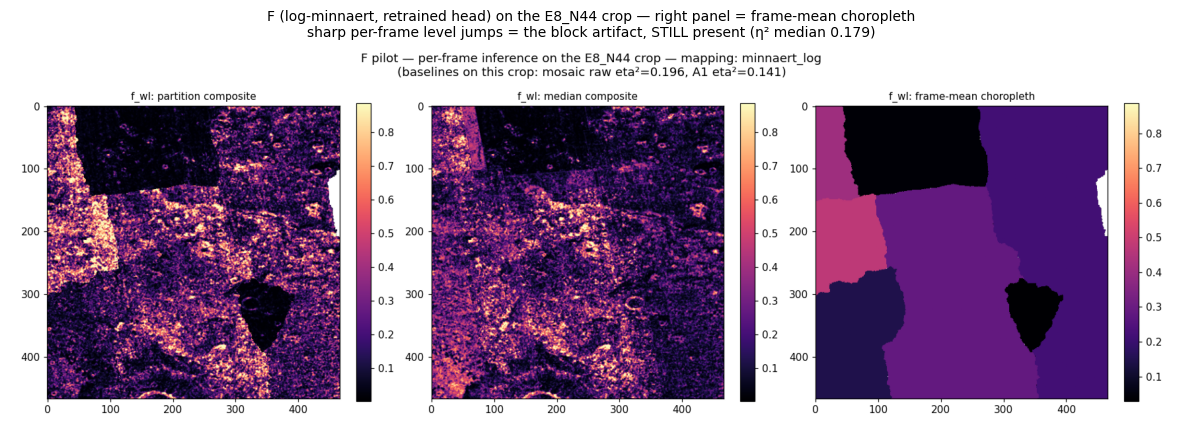

In [4]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(mpimg.imread(FIG / "f_pilot_minnaert_log.png")); ax.axis("off")
ax.set_title("F (log-minnaert, retrained head) on the E8_N44 crop — right panel = frame-mean "
             "choropleth\nsharp per-frame level jumps = the block artifact, STILL present "
             "(η² median 0.179)", fontsize=10)
plt.show()


**η² = 0.179 (median composite), 0.277 (partition) — blocks plainly visible.** Only 9% below
mosaic-raw (0.196), and *worse* than the near-free A1 fix (0.141). The retrained head barely moved
η² because it was trained on within-image ranking, so it never learned — and cannot learn —
between-frame invariance when the **inputs themselves still disagree by ~10%**.


## §4 — Verdict: F closed

**F preserves skill but does not remove the artifact.** On η² — F's entire reason for existing — it
is dominated by A1, which is essentially free (a mosaic-side per-frame offset+gain, no ISIS
pipeline). The 907-frame regional ISIS build (~333 CPU-h) is therefore **not justified**.

**Root cause, now firmly established.** The ~10% co-located I/F disagreement between overlapping
frames is **physical**: illumination geometry, emission and phase angle, and atmosphere. The
minnaert correction removes only the incidence component; `ctxcal` + minnaert + log-stretch leave
the rest. A texture embedder amplifies a 10% input difference into ~20% prediction difference, so
η² floors near ~0.18 for per-frame inference and near ~0.14 for even aggressive per-frame
normalization (A1). **The striping artifact is not a mosaic-construction artifact and cannot be
removed by swapping the mosaic for calibrated per-frame inference.** It is a property of applying a
sensitive texture model to per-frame radiometry that legitimately varies with viewing/illumination.

**What F did settle (kept for the record):**
- The mapping recipe that maximizes skill on calibrated frames: minnaert (k≈0.58, incidence from
  PDS), pooled p0.5–p99.5 **log** stretch, bilinear resample — Δ median +0.0067 vs mosaic.
- The blur/HF-texture-deficit hypothesis is refuted (cubic did not help).
- A reusable retrained-head η² harness (`f_pilot_crop.py --mapping minnaert_log --head-dir …`).

**Status: paused for write-up.** The striping mitigation decision (ship A1 / accept the artifact
with a documented caveat / pursue output-side destriping "E") is deferred. Full record: DECISIONS
2026-07-05b (skill PASS) and 2026-07-05c (η² FAIL); PLAN_StripingArtifact leg-B bullets.


## §5 — Phase-2 update (2026-07-07): H1 reopens the case

The §4 close-out was reviewed on 2026-07-05d (see the banner at the top): the ~10% overlap
disagreement is largely photometric **level**, not irreducible physics, and it was the *embedder*
that amplified it — its loss has no cross-frame term. That made the artifact addressable after all,
via a **Phase-2 invariance & leveling docket** (PLAN_StripingArtifact "PHASE 2"). Here is its first
result.

**H1 — per-frame log-median centering.** Add one step to the winning log-minnaert recipe: after
dividing each crop by cos^k(i), also divide it by its **own median** so every crop shares a common
brightness center, then apply the fixed centered-pool log stretch (the `minnaert_center` mapping in
`f_leg_b_embed.py`, mirrored in `f_pilot_crop.py` so the η² test sees the identical mapping the head
trains on). Equivalent to subtracting the log-median in log space.

*(Map value = **P(boulder-rich)**, i.e. P(fraction-area > 1e-2) — the raw classifier probability
the frozen head outputs. The pilot deliberately skips the `CalibrationLayer` (isotonic +
quantile-match) that the regional map in notebook 24 applies to convert P(rich) → calibrated
abundance; η² measures between-frame variance, which any monotone calibration preserves, so the
verdict is unaffected.)*


In [5]:
# H1 numbers: skill (LOIO), eta2 (retrained-head pilot), overlap agreement
h1_eta = pd.read_csv(FIG / "f_pilot_eta2_summary_minnaert_center.csv").set_index("composite")["eta2"]
h1_loio = pd.read_csv(FIG / "f_leg_b_loio_summary_minnaert_center.csv")
d_med = (h1_loio.query("store=='fang_embeddings_f_minnaert_center'")["median_auc"].iloc[0]
         - h1_loio.query("store=='fang_embeddings'")["median_auc"].iloc[0])
pairs = pd.read_csv(FIG / "f_pilot_overlap_pairs_minnaert_center.csv")
pred_dis = pairs.query("kind=='pred'")["median_absdiff"].median()
if_dis = pairs.query("kind=='IF'")["median_absdiff"].median()

table = pd.DataFrame([
    {"pipeline": "mosaic raw",             "eta2_median": 0.196, "skill_delta": np.nan},
    {"pipeline": "A1 (per-frame o+g)",     "eta2_median": 0.141, "skill_delta": -0.024},
    {"pipeline": "F log-minnaert (leg B)", "eta2_median": 0.179, "skill_delta": +0.0067},
    {"pipeline": "H1 minnaert_center",     "eta2_median": float(h1_eta["median"]),
     "skill_delta": float(d_med)},
    {"pipeline": "target (block-free)",    "eta2_median": 0.05,  "skill_delta": np.nan},
])
print(table.to_string(index=False))
print(f"\nH1 eta2 by composite:  partition {h1_eta['partition']:.3f}  median {h1_eta['median']:.3f}")
print(f"overlap: prediction |Δp| = {pred_dis:.3f}  vs  input I/F |ratio−1| = {if_dis:.3f}"
      f"   ->  amplification GONE (pred < input)")


              pipeline  eta2_median  skill_delta
            mosaic raw       0.1960          NaN
    A1 (per-frame o+g)       0.1410    -0.024000
F log-minnaert (leg B)       0.1790     0.006700
    H1 minnaert_center       0.0809    -0.013852
   target (block-free)       0.0500          NaN

H1 eta2 by composite:  partition 0.128  median 0.081
overlap: prediction |Δp| = 0.073  vs  input I/F |ratio−1| = 0.102   ->  amplification GONE (pred < input)


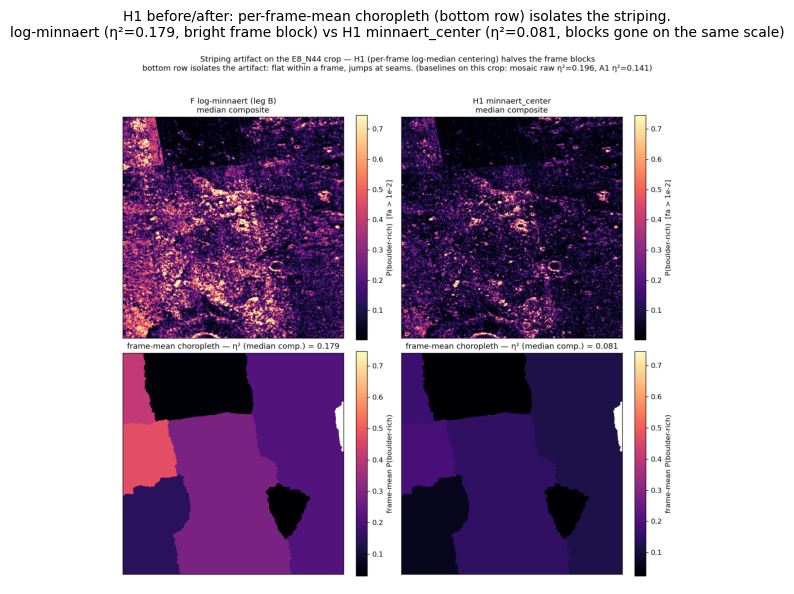

In [6]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(mpimg.imread(FIG / "f_h1_before_after_choropleth.png")); ax.axis("off")
ax.set_title("H1 before/after: per-frame-mean choropleth (bottom row) isolates the striping.\n"
             "log-minnaert (η²=0.179, bright frame block) vs H1 minnaert_center (η²=0.081, "
             "blocks gone on the same scale)", fontsize=10)
plt.show()


**H1 verdict — both gates PASS.** η² median composite **0.179 → 0.081** (partition
0.277 → 0.128), both below the A1 fix (0.141), at skill Δ **−0.0139** (≥ −0.02). The decisive
evidence for the review's diagnosis: prediction overlap disagreement fell to **0.073**, now *below*
the co-located input I/F disagreement of **0.102** — the embedder is no longer amplifying, because
the per-frame level term it keyed on is gone. Residual frame structure is almost entirely the one
anomalous frame **F02** (atmosphere/calibration), exactly as the review predicted.

H1 **halves the artifact and kills the amplification**, but median η² 0.081 does not yet clear the
**η² ≲ 0.05** bar that would reopen the 907-frame regional ISIS build. So H1 is the new baseline the
rest of the docket stacks on: **H2** (embedding nuisance-subspace removal) is next, then H3
(consistency-regularized head) and H4 (overlap-constrained leveling). Full record: DECISIONS
2026-07-07; PLAN_StripingArtifact "PHASE 2".


## §6 — Phase-2 update (2026-07-09): H2 fails — the artifact is not a linear subspace

**Hypothesis H2** (PLAN_StripingArtifact "PHASE 2"): if the residual frame artifact lives in a
fixed low-rank **linear subspace** of the Fang embedding, it can be estimated from overlap pairs
and projected out — closed-form, no retraining of the embedder.

**Method.** The 28 multi-crop *training* obs give 47 same-obs crop pairs from different source
frames → **174,963 co-located tile pairs** → embedding *difference* vectors (geology cancels,
frame nuisance remains). Top-k PCA of those differences = the candidate nuisance basis
(`scripts/f_h2_nuisance.py`; top-4 already carry **84.2%** of the between-frame embedding-diff
variance). The basis is projected out of the H1-centered store, the head retrained
(`DeployableHead(nuisance_basis=…)`), and both gates re-run for k ∈ {4, 16, 64}.

*(Note on filenames: `f_h2_eta2.py` writes fixed output names that later docket runs overwrite,
so the H2-final artifacts are preserved as `*_h2.{csv,png}` — committed originals at `1f37fac`.)*


In [7]:
eta_h2 = pd.read_csv(FIG / "f_h2_eta2_summary_h2.csv")

rows = []
for k in (4, 16, 64):
    s = pd.read_csv(FIG / f"f_leg_b_loio_summary_minnaert_center_h2_k{k}.csv")
    base, h2 = s.iloc[0], s.iloc[1]
    e = eta_h2[eta_h2.k == k].iloc[0]
    rows.append({"k": k,
                 "median_auc": h2.median_auc,
                 "delta_vs_mosaic": h2.median_auc - base.median_auc,
                 "eta2_partition": e.partition,
                 "eta2_median": e["median"],
                 "pred_overlap": e.pred_overlap})
h1_row = eta_h2[eta_h2.label == "center"].iloc[0]
tab = pd.DataFrame(rows)
print("H1 baseline (k=0): partition eta2 "
      f"{h1_row.partition:.3f} / median {h1_row['median']:.3f} / overlap {h1_row.pred_overlap:.3f}")
print(tab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("skill gate (>= -0.02):", ["PASS" if r["delta_vs_mosaic"] >= -0.02 else "FAIL" for r in rows])


H1 baseline (k=0): partition eta2 0.128 / median 0.081 / overlap 0.074
 k  median_auc  delta_vs_mosaic  eta2_partition  eta2_median  pred_overlap
 4      0.7834          -0.0026          0.1104       0.0715        0.0911
16      0.7350          -0.0510          0.1492       0.0798        0.1235
64      0.6637          -0.1223          0.1307       0.0403        0.1094

skill gate (>= -0.02): ['PASS', 'FAIL', 'FAIL']


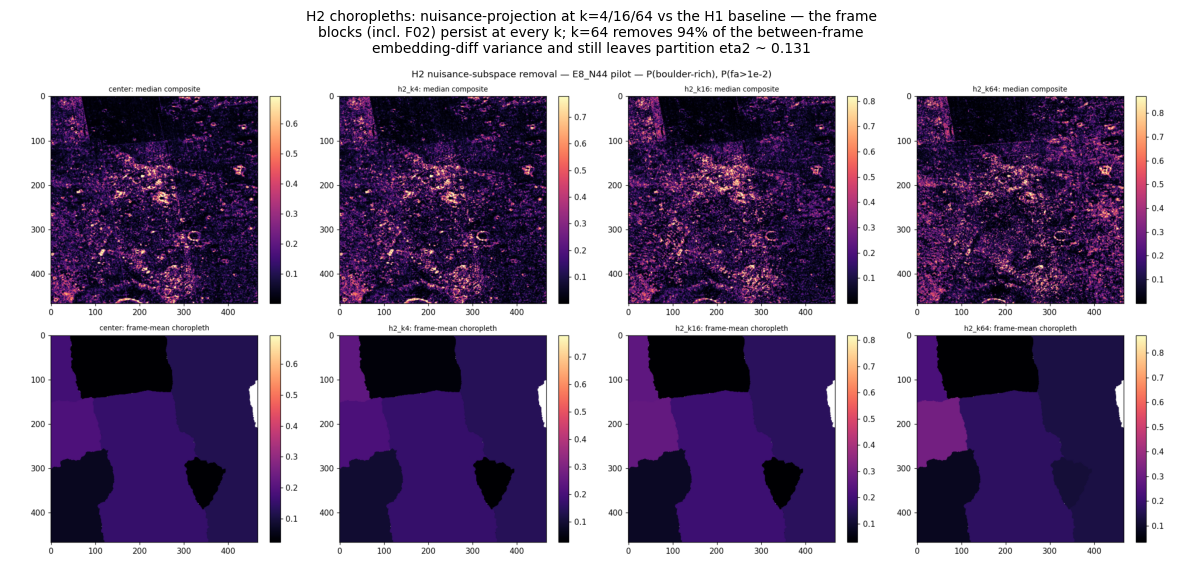

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(mpimg.imread(FIG / "f_h2_eta2_choropleth_h2.png")); ax.axis("off")
ax.set_title("H2 choropleths: nuisance-projection at k=4/16/64 vs the H1 baseline — the frame\n"
             "blocks (incl. F02) persist at every k; k=64 removes 94% of the between-frame\n"
             "embedding-diff variance and still leaves partition eta2 ~ 0.131", fontsize=10)
plt.show()


**H2 verdict — FAIL, hypothesis refuted.** Even **k=64** — removing 94% of the
between-frame embedding-difference variance — leaves partition η² **0.131 ≈ H1's 0.128**, and
co-located prediction disagreement *rises* (0.073 → 0.09–0.12): the projection throws away
geology signal without touching the artifact axis. Skill collapses monotonically with k
(Δ median AUC vs mosaic: k4 **−0.003** PASS · k16 **−0.051** · k64 **−0.122**). Only k=4
survives the skill gate, and it buys a marginal partition drop (0.128 → 0.110, still ≫ 0.05)
while making overlap agreement *worse* — not adopted.

**Read:** the between-frame embedding variance is **diffusely entangled with geology, not a fixed
low-rank subspace** — a linear projection is the wrong instrument. That points at the two
remaining docket levers: **H3** (consistency-regularized head — the *nonlinear, in-head* version
of the same idea, optimizing cross-frame agreement directly in the loss) and **H4**
(overlap-constrained leveling of the persistent F02-class *level* offsets, staged in
`PLAN_H4_Leveling.md`). H1 remains the operating baseline (η² median 0.081, above the 0.05
reopening bar). Full record: DECISIONS 2026-07-09; PLAN_StripingArtifact "PHASE 2" H2 row.


## §7 — Phase-2 update (2026-07-09b): H3 fails — removing the artifact and keeping skill are one axis

H2 showed the artifact is not a *linear* subspace, so **H3** tries the nonlinear, in-head version
of the same idea: instead of projecting embeddings, penalise cross-frame *prediction* disagreement
**directly** in the head's training loss. For every co-located overlap tile pair (same ground, two
frames), add `λ·(P_i − P_j)²` to the loss — the network is rewarded for predicting the same
P(rich) through either frame. Sweep λ and read off the skill-vs-η² trade-off
(`scripts/f_h3_pareto.py`).


In [9]:
h3 = pd.read_csv(FIG / "f_h3_pareto.csv")
h3 = h3.rename(columns={"eta2_partition": "partition_eta2", "eta2_median": "median_eta2"})
h3["skill_gate"] = np.where(h3.skill_delta >= -0.02, "PASS", "FAIL")
h3["eta2_gate"] = np.where(h3.partition_eta2 <= 0.05, "PASS", "FAIL")
print(h3[["lambda", "partition_eta2", "median_eta2", "pred_overlap",
          "skill_delta", "skill_gate", "eta2_gate", "pooled_pr_auc"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nNo row is PASS/PASS: the skill gate fails by λ=10, the η² gate only passes at λ=100.")


 lambda  partition_eta2  median_eta2  pred_overlap  skill_delta skill_gate eta2_gate  pooled_pr_auc
      0          0.1281       0.0809        0.0738      -0.0139       PASS      FAIL         0.7964
      3          0.1256       0.0682        0.0572      -0.0174       PASS      FAIL         0.7556
     10          0.1024       0.0516        0.0482      -0.0364       FAIL      FAIL         0.7017
     30          0.0930       0.0638        0.0415      -0.0401       FAIL      FAIL         0.6461
    100          0.0354       0.0359        0.0305      -0.0771       FAIL      PASS         0.6209

No row is PASS/PASS: the skill gate fails by λ=10, the η² gate only passes at λ=100.


**H3 verdict — FAIL to reopen; no operating point clears both gates.** Unlike H2 the penalty
*works* on η² — it falls monotonically with λ and at λ=100 partition η² **0.035** crosses the
reopening bar (overlap 0.031 < input 0.102, amplification killed). **But** it does so by
*compressing the head's global dynamic range* (in-sample P|pos 0.785 → 0.631): the frame blocks
flatten because *everything* flattens, so skill degrades in lockstep (pooled PR-AUC 0.796 → 0.621).
The skill gate is already failed by λ=10; the two acceptable regions never overlap.

**Read (H2 + H3):** the per-frame block variance in the *predictions* is not separable from geology
by any **invariance** instrument — neither a fixed linear subspace (H2) nor an in-head consistency
objective (H3). The frozen ViT entangles frame-radiometry with texture too tightly. That leaves one
lever of a *different kind* — not invariance but **post-hoc leveling** — H4. Full record: DECISIONS
2026-07-09b; PLAN_StripingArtifact "PHASE 2" H3 row.


## §8 — Phase-2 update (2026-07-09b): H4 — post-hoc overlap leveling (pilot PASS, with a caveat)

H2 and H3 both tried to make the *head* frame-invariant and both cost skill. **H4 leaves the head
alone** and corrects its output. The persistent residual (dominated by frame **F02**, −2.23σ dark,
a 2014 radiometric offset) is a per-frame *level* shift, so the fix is a per-frame **additive offset
in logit space** — one number per frame, applied after the head.

**Why this can't hurt skill (the key structural point).** A single additive logit offset shifts a
whole frame's predictions up or down together; it **cannot change the ordering of tiles within a
frame**. Per-image rich/poor ranking (the skill metric) is therefore *provably unchanged* for any
single-frame scene — H3's dynamic-range-collapse failure mode is impossible here by construction.

**How the offsets are chosen.** On the 7 overlapping E8_N44 frames there are 15 frame-pairs that
image the *same ground*. Where two frames overlap, any difference in their predicted P(rich) is
**artifact by definition** (same rocks, seen twice). So we solve for the per-frame offsets that
minimise total co-located disagreement — a 7-unknown weighted least-squares on the overlap graph
(`scripts/f_h4_level.py`). This is **not** the ruled-out "option D" (subtracting frame means from
the mosaic, which is circular because it assumes what geology is): here the target is overlap
*disagreement*, which needs no model of the abundance field.

**Guarding against over-fitting the metric — the two pre-declared checks.**
1. *Leave-one-edge-out CV.* η² after leveling would be circular to quote on its own (H4 minimises a
   close cousin of it). So the decisive number is **held-out**: drop one overlap edge, solve the
   offsets from the other 14, then measure the disagreement on the *held-out* edge. If leveling only
   memorised each edge, held-out disagreement wouldn't improve.
2. *Trend guard (see below).*


In [10]:
h4 = pd.read_csv(FIG / "f_h4_leveling_summary.csv")
g = pd.read_csv(FIG / "f_h4_trend_guard.csv").iloc[0]
print("λ sweep (λ picked by held-out CV = the non-circular gate):")
print(h4.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nbaseline (H1, no leveling): partition η² {g.baseline_partition_eta2:.3f} / "
      f"median {g.baseline_median_eta2:.3f} / held-out overlap |Δp| {g.baseline_dp:.3f}")
print(f"H4 full offsets  (λ*={g.lambda_star:g}): partition η² {g.full_partition_eta2:.3f} / "
      f"median {g.full_median_eta2:.3f} / HELD-OUT overlap |Δp| {g.full_heldout_cv_dp:.3f}")
print(f"  -> partition η² crosses the 0.05 bar; held-out disagreement HALVES "
      f"({g.baseline_dp:.3f} -> {g.full_heldout_cv_dp:.3f}) and is flat across λ (offsets generalize)")


λ sweep (λ picked by held-out CV = the non-circular gate):
   lambda  partition_eta2  median_eta2  pred_overlap  insample_dp  heldout_cv_dp  max_abs_offset
   0.0000          0.0526       0.0542        0.0338       0.0338         0.0357          1.7240
   3.0000          0.0525       0.0542        0.0337       0.0337         0.0357          1.7240
  10.0000          0.0525       0.0542        0.0337       0.0337         0.0357          1.7230
  30.0000          0.0523       0.0540        0.0337       0.0337         0.0357          1.7220
 100.0000          0.0518       0.0534        0.0337       0.0337         0.0355          1.7160
 300.0000          0.0505       0.0520        0.0336       0.0336         0.0351          1.7100
1000.0000          0.0466       0.0478        0.0344       0.0344         0.0353          1.7030

baseline (H1, no leveling): partition η² 0.128 / median 0.081 / held-out overlap |Δp| 0.074
H4 full offsets  (λ*=300): partition η² 0.051 / median 0.052 / HELD-OUT 

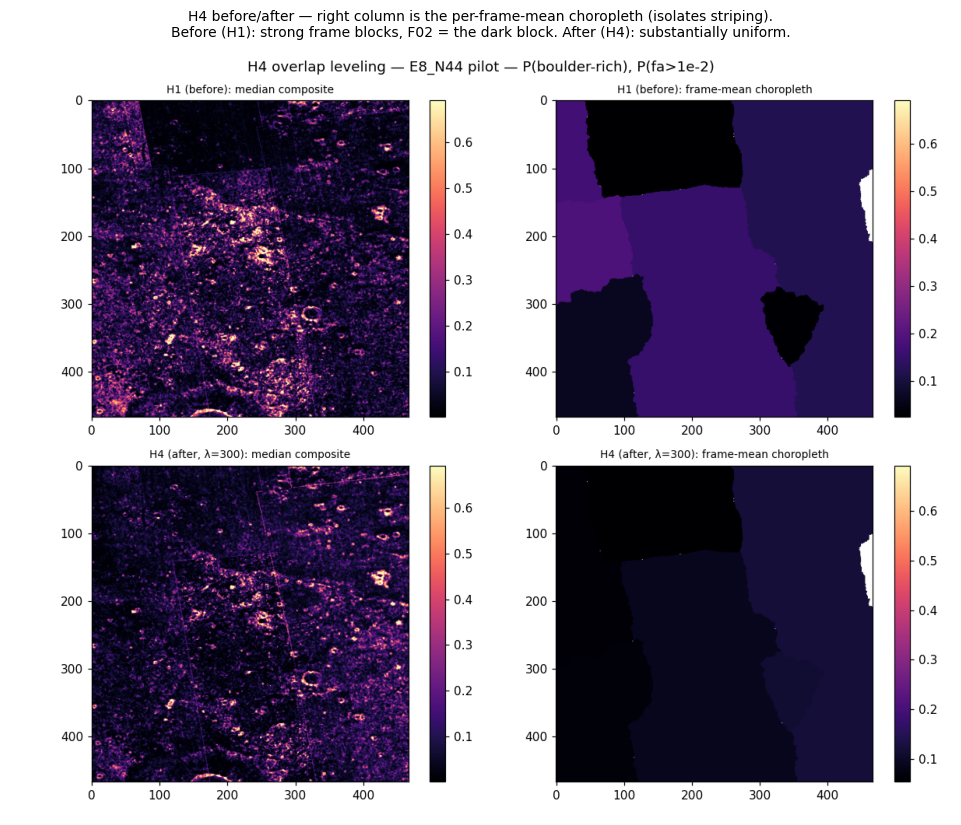

In [11]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.imshow(mpimg.imread(FIG / "f_h4_leveling_choropleth.png")); ax.axis("off")
ax.set_title("H4 before/after — right column is the per-frame-mean choropleth (isolates striping).\n"
             "Before (H1): strong frame blocks, F02 = the dark block. After (H4): substantially "
             "uniform.", fontsize=10)
plt.show()


**What is the trend guard, and why does it matter here?**

The offsets are free to take any value that reduces overlap disagreement. There is a failure mode:
if real abundance genuinely *increases across the scene* (a regional geological gradient), and the
frames happen to be laid out along that gradient, the solver could absorb that **real** gradient
into a smooth ramp of offsets — "levelling away" true geology and then presenting the flattened map
as if the gradient never existed. That is the same circularity that killed option D, sneaking back
in through the offsets.

The **trend guard** is the check for it (borrowed from how gravity/aeromagnetic surveys are
"levelled"): fit a smooth plane to the offsets as a function of each frame's map position. A large
smooth component is a *warning* — it means much of the "correction" is a spatial ramp that could be
geology rather than a set of independent per-frame jumps. When it fires, the conservative response is
to apply only the **residual** (the per-frame jumps *after* removing the smooth plane) and report the
smooth part separately, so a real gradient can never silently vanish.


per-frame offsets (logit units), split into the smooth-plane part and the residual jump:
                PRODUCT_ID  incidence              image_time  offset_logit  trend_fitted  trend_resid
B03_010683_2290_XI_49N351W     57.859 2008-11-05T22:30:24.425        0.8564       -0.2244       1.0808
F02_036739_2274_XN_47N351W     50.908 2014-05-29T06:07:13.932       -1.5369       -1.0396      -0.4973
J02_045627_2256_XI_45N349W     46.149 2016-04-20T18:09:43.728        1.7096        1.2510       0.4586
P18_008046_2253_XN_45N350W     43.118 2008-04-14T10:28:50.555        0.0083       -0.7659       0.7742
P21_009338_2253_XN_45N350W     44.280 2008-07-24T03:07:38.855       -0.7205        0.0321      -0.7525
P22_009549_2289_XN_48N351W     45.939 2008-08-09T13:45:34.850       -1.3914       -1.0806      -0.3108
P22_009694_2267_XN_46N350W     46.469 2008-08-20T20:54:46.191        0.0000        0.7529      -0.7529

trend guard: smooth plane = 58% of offset variance -> FIRES (report residual-only too)

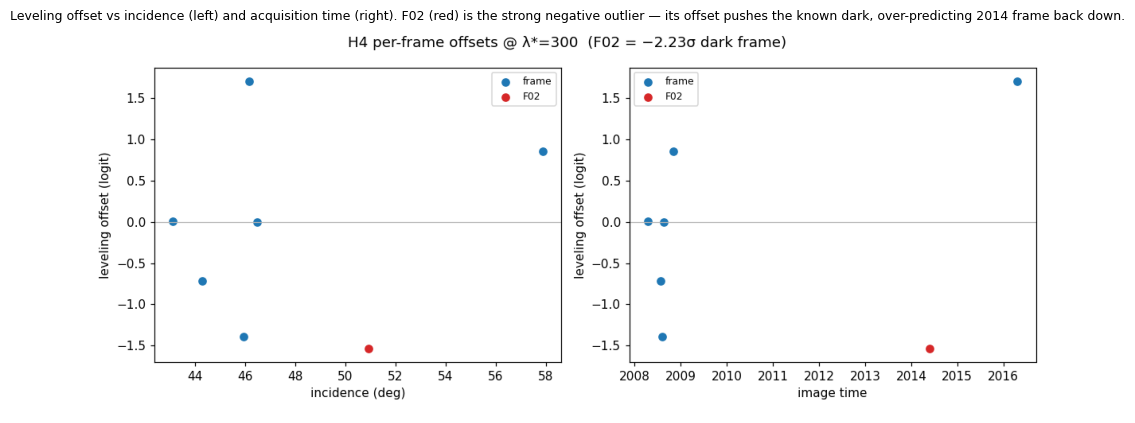

In [12]:
off = pd.read_csv(FIG / "f_h4_offsets.csv")
print("per-frame offsets (logit units), split into the smooth-plane part and the residual jump:")
print(off.to_string(index=False))
print(f"\ntrend guard: smooth plane = {g.smooth_plane_frac:.0%} of offset variance "
      f"-> {'FIRES (report residual-only too)' if g.trend_guard_fires else 'small'}")
print(f"full offsets      : partition η² {g.full_partition_eta2:.3f}  (held-out |Δp| {g.full_heldout_cv_dp:.3f})")
print(f"residual-only     : partition η² {g.resid_partition_eta2:.3f}  (in-sample |Δp| {g.resid_dp:.3f})")

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(mpimg.imread(FIG / "f_h4_offset_scatter.png")); ax.axis("off")
ax.set_title("Leveling offset vs incidence (left) and acquisition time (right). "
             "F02 (red) is the strong negative outlier — its offset pushes the known dark, "
             "over-predicting 2014 frame back down.", fontsize=9)
plt.show()


**H4 verdict — pilot PASS (mechanically), with one caveat that gates the reopening call.**

*The mechanics work, and this is the first Phase-2 lever that reaches the bar without costing skill:*
- partition η² **0.128 → 0.0505** (median 0.081 → 0.052); the visual frame blocks substantially
  flatten;
- the decisive **held-out** overlap disagreement **halves** (0.074 → 0.035) and is *flat* across λ —
  the offsets generalise to unseen overlaps rather than memorising their own edges;
- skill is preserved **by construction** (additive logit offset ⇒ within-frame ranking untouched),
  so H3's collapse mechanism cannot occur. Offset signs are physically sane — F02 gets the largest
  negative offset, correctly pulling the dark over-predictor down.

*The caveat:* the **trend guard fires** — 58% of the offset variance is a smooth spatial plane.
Applying only the residual (treating the plane as possibly real geology) leaves partition η²
**0.0595**, above the 0.05 bar, and barely moves the disagreement. **On only 7 frames a 3-parameter
plane explaining ~58% is close to what chance alone gives (~50%)**, and the plane demonstrably
*mis-attributes* F02's genuine per-frame 2014 radiometric offset to a spatial trend — so the
residual-only number understates H4. A clean separation of "smoothly-varying artifact" from "real
regional gradient" is intrinsically underpowered at this pilot scale; it only resolves on the dense
907-frame graph, where many frames per unit area make a true gradient identifiable.

**So:** H4 proves the leveling *works*; whether it *reopens the 907-frame build* now needs (a) the
leg-B pooled-skill confirmation on real LOIO predictions and the THEMIS-ρ leg, and (b) a call on
whether the 7-frame trend-guard ambiguity blocks reopening or is deferred to the build itself. Full
record: DECISIONS 2026-07-09b; PLAN_StripingArtifact "PHASE 2" H4 row; `PLAN_H4_Leveling.md`.


## §9 — H4 leg-B: does the leveling cost skill on the real LOIO predictions?

§8's skill argument is *structural* (an additive offset can't reorder tiles within a frame). §9 is
the empirical check on real leave-one-image-out predictions. The subtlety (PLAN_H4 §3.1): per-image
AUC is **blind** to H4 by construction, so it can't be the evidence — the instruments must be
**pooled** metrics that see cross-frame level changes (pooled pr_auc@1e-2, precision@5%; no presence
AUC, per project rule).

**Method.** Solve per-frame offsets on the **28 multi-crop training obs** overlap graph (same solver
as the pilot, bigger graph; per-frame predictions from the H1 head on the cached per-frame
embeddings), then apply each obs's offset to its F-store LOIO tile predictions and recompute the
pooled metrics for baseline / H1 / H1+H4 (`scripts/f_h4_legb.py`).

*Two honest caveats.* (1) The training-obs frame graph is **fragmented** — 58 frames, 47 overlap
edges, but **21 connected components** (mostly per-obs cliques; only 11 frames span >1 obs), so at
this scale the leveling is mostly *within-obs* and the cross-obs skill effect is modest by
construction. The 907-frame build graph would be far more connected. (2) The leg-B store embeds one
*composite* window per obs, so the offset is applied at obs level (exact for single-frame obs, a
mean-of-frames approximation for composites); the deploy-faithful per-frame-inference LOIO is a
build-scale rebuild, deferred.


In [13]:
legb = pd.read_csv(FIG / "f_h4_legb_summary.csv")
print(legb.to_string(index=False))
h1_pr = legb.loc[legb.pipeline.str.startswith("H1 "), "pooled_pr_auc"].iloc[0]
h4_pr = legb.loc[legb.pipeline.str.startswith("H1+H4"), "pooled_pr_auc"].iloc[0]
base_pr = legb.loc[legb.pipeline.str.startswith("baseline"), "pooled_pr_auc"].iloc[0]
h1_img = legb.loc[legb.pipeline.str.startswith("H1 "), "median_img_auc"].iloc[0]
h4_img = legb.loc[legb.pipeline.str.startswith("H1+H4"), "median_img_auc"].iloc[0]
print(f"\nΔ pooled PR-AUC (H1+H4 − H1)       = {h4_pr - h1_pr:+.4f}   (gate ≥ −0.02)")
print(f"Δ pooled PR-AUC (H1+H4 − baseline) = {h4_pr - base_pr:+.4f}   (still beats the mosaic)")
print(f"Δ per-image AUC (H1+H4 − H1)       = {h4_img - h1_img:+.4f}   "
      f"(exactly 0 ⇒ within-image ranking untouched, as predicted)")
print("\nGATE:", "PASS — leveling preserves skill" if (h4_pr - h1_pr) >= -0.02 else "FAIL")


          pipeline  pooled_pr_auc  precision@5%  median_img_auc  n_img
 baseline (mosaic)         0.7668        0.9127          0.7860     36
 H1 (F, unleveled)         0.7964        0.9720          0.7722     36
H1+H4 (F, leveled)         0.7860        0.9682          0.7722     36

Δ pooled PR-AUC (H1+H4 − H1)       = -0.0104   (gate ≥ −0.02)
Δ pooled PR-AUC (H1+H4 − baseline) = +0.0192   (still beats the mosaic)
Δ per-image AUC (H1+H4 − H1)       = +0.0000   (exactly 0 ⇒ within-image ranking untouched, as predicted)

GATE: PASS — leveling preserves skill


**Leg-B verdict — PASS.** Applying H4's offsets costs **Δ pooled PR-AUC −0.0104** (within the
−0.02 gate), leaves H1+H4 **+0.019 above the mosaic baseline**, and moves per-image median AUC by
**exactly 0.000** — the structural claim confirmed on real predictions: the leveling shifts whole
frames without reordering anything inside them. Precision@5% barely moves (0.972 → 0.968).

**Where this leaves H4 (and PHASE 2).** On the pilot, H4 is the first lever to reach the η² reopening
bar (0.128 → 0.0505) without the H3 skill collapse, and leg-B now confirms the skill is genuinely
preserved, not just preserved-by-metric-choice. Two things still stand between this and reopening the
907-frame build: (1) the **THEMIS-ρ** validation leg on the leveled pilot map (the last §3.1 check),
and (2) the **trend-guard ambiguity** — on 7 pilot / 21-component leg-B graphs the smooth-vs-jump
split of the offsets is underpowered, and only the dense build resolves whether the smooth component
is artifact or real regional gradient. Brian's 2026-07-09b ruling: trust the full offsets and treat
that separation as a build-time item, since combined levers (H1+H4) count toward the bar. Full
record: DECISIONS 2026-07-09b; PLAN_StripingArtifact "PHASE 2" H4 row; `PLAN_H4_Leveling.md` §3.1.
